In [95]:
import numpy as np
import joblib
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

In [96]:
## โหลด Ensemble Model ##
ensemble = joblib.load("garbage_ensemble_model.pkl")
print("Ensemble model loaded ✅")

Ensemble model loaded ✅


In [97]:
##โหลด MobileNet สำหรับดึง Feature
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    pooling='avg',
    input_shape=(224, 224, 3)
)

print("MobileNet loaded ✅")

MobileNet loaded ✅


In [98]:
## กำหนดชื่อคลาส
class_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

In [99]:
# Test
img_path = "Garbage classification\predict\p4.jpg"  # ใส่ชื่อรูปที่ต้องการทำนาย

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

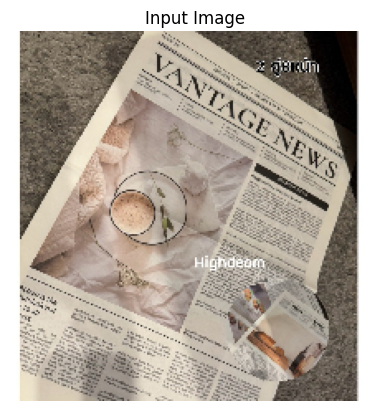

In [100]:
## Preprocess รูป
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

plt.imshow(img)
plt.title("Input Image")
plt.axis("off")

In [101]:
## ดึง Feature
feature = base_model.predict(img_array)
print("Feature shape:", feature.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step
Feature shape: (1, 1280)


In [102]:
## ทำนายผล
prediction = ensemble.predict(feature)
probabilities = ensemble.predict_proba(feature)

pred_class = class_names[prediction[0]]
confidence = np.max(probabilities)

print("Prediction:", pred_class)
print("Confidence:", round(confidence * 100, 2), "%")

Prediction: paper
Confidence: 80.81 %
